# TextMamba3D — A100 Full Training Pipeline (v4.3)

**Target:** Single A100 40GB (Colab)
**Architecture:** v4.3 — PWAM multiplicative fusion + Text-to-Voxel Loss + Text Necessity Loss + Embedding Perturbation
**Baseline:** v4.2 Mean Dice = TBD (text delta ~ -0.02%)
**Goal:** Make text guidance measurably beneficial through structural and loss-level enforcement

v4.3 changes vs v4.2:
- **PWAM3D**: Multiplicative fusion replaces additive PixelTextCrossAttention (LAVT CVPR'22)
- **TextToVoxelLoss**: CRIS-style text-conditioned per-voxel BCE with 3 BraTS regions (ET/TC/WT)
- **TextNecessityLoss**: Hinge on soft Dice delta between text-guided and null-text predictions
- **EmbeddingPerturbation**: Learned directional perturbation in embedding space (simplified RLEG)
- **Learned null text embedding**: Same graph structure for no-text path (not bypass)
- **Phase A/B training**: Phase A (epoch 0-30) = Dice+CE+T2V; Phase B (30+) += Necessity

**VRAM estimate:** Phase A ~34-38 GB, Phase B ~36-39 GB (no_grad null-text pass)
**Checkpoint incompatibility:** V4.2 checkpoints NOT compatible — must train from scratch.

In [1]:
# Mount Google Drive (run in Colab web UI if using VS Code plugin)
from google.colab import drive
drive.mount('/content/drive')

# Install packages (cached on Drive)
!nvidia-smi
!pip install -q --cache-dir=/content/drive/MyDrive/pip_cache mamba-ssm causal-conv1d transformers nibabel tensorboard pyyaml tqdm

Mounted at /content/drive
Sat Mar 14 05:37:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+---------------------

In [2]:
import os, shutil, zipfile

REPO_DIR = '/content/TextMamba3D'
DRIVE_BASE = '/content/drive/MyDrive/TextMamba3D'

# Deploy code from Drive
if not os.path.exists(REPO_DIR):
    src = os.path.join(DRIVE_BASE, 'TextMamba3D_code')
    if os.path.exists(src):
        shutil.copytree(src, REPO_DIR)
        print(f'Copied code from {src}')
    else:
        print(f'ERROR: {src} not found on Drive')
else:
    print(f'Repo already exists at {REPO_DIR}')

os.chdir(REPO_DIR)
print(f'Working directory: {os.getcwd()}')

# Extract BraTS data
DATA_ZIP = os.path.join(DRIVE_BASE, "TextBraTS_data.zip")
DATA_DIR = os.path.join(REPO_DIR, "data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

if not os.path.exists(DATA_DIR):
    os.makedirs(os.path.dirname(DATA_DIR), exist_ok=True)
    if os.path.exists(DATA_ZIP):
        print(f"Extracting {DATA_ZIP} ...")
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(os.path.dirname(DATA_DIR))
        print(f"Done. Cases found: {len(os.listdir(DATA_DIR))}")
    else:
        print(f"ERROR: Data zip not found at {DATA_ZIP}")
else:
    print(f"Data already extracted. Cases: {len(os.listdir(DATA_DIR))}")

Copied code from /content/drive/MyDrive/TextMamba3D/TextMamba3D_code
Working directory: /content/TextMamba3D
Extracting /content/drive/MyDrive/TextMamba3D/TextBraTS_data.zip ...
Done. Cases found: 371


## 3. V4.3 Code Patches

Apply all v4.3 architectural changes: PWAM fusion, embedding perturbation,
text-to-voxel loss, text necessity loss, model rewrite, training loop update.

In [3]:
import pathlib, os
os.chdir(REPO_DIR)

print("=" * 60)
print("V4.3 Patch: PWAM + Text-Guided Losses + Embedding Perturbation")
print("=" * 60)

# [v4.3-1] Create models/pwam.py
pathlib.Path('models/pwam.py').write_text('''
# models/pwam.py
"""PWAM3D: Pixel-Word Attention Module for 3D medical image segmentation.

Adapted from LAVT (CVPR 2022) for 3D volumetric data.
Key: cross-attention + multiplicative fusion + gated residual.
InstanceNorm1d on Q and output projections (critical: +2.07 oIoU in LAVT).
"""

import torch
import torch.nn as nn


class PWAM3D(nn.Module):
    """Pixel-Word Attention Module adapted for 3D.

    Cross-attention between visual and language tokens,
    followed by multiplicative fusion and gated residual.
    """

    def __init__(self, vis_dim: int, lang_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        self.vis_dim = vis_dim
        self.q_proj = nn.Sequential(
            nn.Conv1d(vis_dim, vis_dim, 1),
            nn.InstanceNorm1d(vis_dim),
        )
        self.k_proj = nn.Conv1d(lang_dim, vis_dim, 1)
        self.v_proj = nn.Conv1d(lang_dim, vis_dim, 1)
        self.out_proj = nn.Sequential(
            nn.Conv1d(vis_dim, vis_dim, 1),
            nn.InstanceNorm1d(vis_dim),
        )
        self.vis_proj = nn.Sequential(
            nn.Conv1d(vis_dim, vis_dim, 1),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.mm_proj = nn.Sequential(
            nn.Conv1d(vis_dim, vis_dim, 1),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.gate = nn.Sequential(
            nn.Linear(vis_dim, vis_dim, bias=False),
            nn.ReLU(),
            nn.Linear(vis_dim, vis_dim, bias=False),
            nn.Tanh(),
        )
        self.scale = vis_dim ** -0.5

    def forward(self, vis, lang_tokens, lang_mask):
        """
        Args:
            vis: [B, N, C] visual tokens
            lang_tokens: [B, T, lang_dim] language tokens
            lang_mask: [B, T] attention mask (1=valid, 0=pad), or None
        Returns:
            [B, N, C] fused visual tokens
        """
        B, N, C = vis.shape
        if lang_mask is None:
            lang_mask = torch.ones(B, lang_tokens.shape[1], device=vis.device)
        vis_t = vis.transpose(1, 2)
        lang_t = lang_tokens.transpose(1, 2)

        q = self.q_proj(vis_t).transpose(1, 2)
        k = self.k_proj(lang_t).transpose(1, 2)
        v = self.v_proj(lang_t).transpose(1, 2)

        attn = torch.bmm(q, k.transpose(1, 2)) * self.scale
        mask_3d = lang_mask.unsqueeze(1).float()
        attn = attn.masked_fill(mask_3d == 0, float('-inf'))
        attn = torch.softmax(attn, dim=-1)
        attn = attn.masked_fill(mask_3d == 0, 0.0)

        lang_feat = torch.bmm(attn, v)
        lang_feat = self.out_proj(lang_feat.transpose(1, 2)).transpose(1, 2)

        fused = lang_feat * self.vis_proj(vis_t).transpose(1, 2)
        fused = self.mm_proj(fused.transpose(1, 2)).transpose(1, 2)

        gate = self.gate(fused.mean(dim=1)).unsqueeze(1)
        return gate * fused + vis


class MultiScalePWAM(nn.Module):
    """Apply PWAM3D at multiple encoder stages."""

    def __init__(self, stage_dims: list, lang_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        self.pwams = nn.ModuleList([
            PWAM3D(vis_dim=dim, lang_dim=lang_dim, dropout=dropout)
            for dim in stage_dims
        ])

    def forward(self, img_features, text_features, attention_mask):
        """
        Args:
            img_features: list of [B, N_i, C_i]
            text_features: [B, T, lang_dim]
            attention_mask: [B, T]
        """
        return [
            pwam(img, text_features, attention_mask)
            for pwam, img in zip(self.pwams, img_features)
        ]
''')
print("[v4.3-1] Created models/pwam.py (PWAM3D + MultiScalePWAM)")

# [v4.3-1b] Patch decoder_3d.py for return_pre_logit
dec_path = pathlib.Path("models/decoder_3d.py")
dec_text = dec_path.read_text()
if "return_pre_logit" not in dec_text:
    dec_text = dec_text.replace(
        "def forward(self, features: list) -> torch.Tensor:",
        "def forward(self, features: list, return_pre_logit: bool = False) -> torch.Tensor:",
    )
    dec_text = dec_text.replace(
        "        x = self.final_proj(x)\n\n        return x",
        "        pre_logit = x\n        x = self.final_proj(x)\n\n        if return_pre_logit:\n            return x, pre_logit\n        return x",
    )
    dec_path.write_text(dec_text)
    # Verify patch applied
    assert "return_pre_logit" in dec_path.read_text(), "ERROR: decoder_3d.py patch failed — return_pre_logit not found"
    print("[v4.3-1b] Patched decoder_3d.py (return_pre_logit) — verified")
else:
    print("[v4.3-1b] decoder_3d.py already patched")

V4.3 Patch: PWAM + Text-Guided Losses + Embedding Perturbation
[v4.3-1] Created models/pwam.py (PWAM3D + MultiScalePWAM)
[v4.3-1b] Patched decoder_3d.py (return_pre_logit) — verified


In [4]:
import pathlib

pathlib.Path('models/embedding_perturbation.py').write_text('''
# models/embedding_perturbation.py
"""Embedding Perturbation for text augmentation.

Simplified from RLEG (ICML 2023): learned directional perturbations
in embedding space. Training only; zero overhead at inference.
"""

import torch
import torch.nn as nn


class EmbeddingPerturbation(nn.Module):
    """Learned embedding-space perturbation."""

    def __init__(self, embed_dim: int = 256, num_directions: int = 8):
        super().__init__()
        self.directions = nn.Parameter(torch.randn(num_directions, embed_dim) * 0.01)
        self.scale = nn.Parameter(torch.ones(num_directions) * 0.1)

    def forward(self, text_emb, training=True):
        """
        Args:
            text_emb: [B, T, embed_dim]
            training: apply perturbation only during training
        """
        if not training:
            return text_emb
        B = text_emb.shape[0]
        coeffs = torch.randn(B, self.directions.shape[0], device=text_emb.device)
        perturbation = torch.einsum('bn,nd->bd', coeffs * self.scale, self.directions)
        return text_emb + perturbation.unsqueeze(1)
''')
print("[v4.3-2] Created models/embedding_perturbation.py")

[v4.3-2] Created models/embedding_perturbation.py


In [5]:
import pathlib

pathlib.Path('losses/text_voxel_loss.py').write_text('''
# losses/text_voxel_loss.py
"""Text-to-Voxel Loss for text-guided 3D segmentation.

Adapted from CRIS (CVPR 2022): text-conditioned dynamic convolution
with 3 BraTS region targets (ET, TC, WT). Batched dot product.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class TextToVoxelLoss(nn.Module):
    """Text-conditioned per-voxel prediction loss."""

    def __init__(self, vis_dim: int, text_dim: int = 256, num_regions: int = 3):
        super().__init__()
        self.vis_dim = vis_dim
        self.num_regions = num_regions
        self.text_to_kernel = nn.Linear(text_dim, vis_dim * num_regions)
        self.bias = nn.Parameter(torch.zeros(num_regions))

    def forward(self, voxel_features, text_global, gt_mask, tumor_ratio):
        """
        Args:
            voxel_features: [B, C, D, H, W] pre-logit decoder feature map
            text_global: [B, text_dim] global text feature (CLS token)
            gt_mask: [B, D_orig, H_orig, W_orig] class labels (0-3)
            tumor_ratio: [B] fraction of tumor voxels
        """
        valid = tumor_ratio > 0.01
        if not valid.any():
            return torch.tensor(0.0, device=voxel_features.device, requires_grad=True)

        # Downsample pre-logit features to reduce VRAM
        # Full-res [B, 48, 128, 128, 128] → [B, 48, 32, 32, 32] saves ~1.2 GB
        if voxel_features.shape[2] > 32:
            voxel_features = F.avg_pool3d(voxel_features, kernel_size=4)

        B, C, D, H, W = voxel_features.shape

        kernels = self.text_to_kernel(text_global)
        kernels = kernels.view(B, self.num_regions, C, 1, 1, 1)

        x = voxel_features.unsqueeze(1)
        logits = (x * kernels).sum(dim=2)
        logits = logits + self.bias.view(1, self.num_regions, 1, 1, 1)

        gt_resized = F.interpolate(
            gt_mask.unsqueeze(1).float(), size=(D, H, W), mode='nearest',
        ).squeeze(1).long()

        target_et = (gt_resized == 3).float()
        target_tc = ((gt_resized == 1) | (gt_resized == 3)).float()
        target_wt = (gt_resized > 0).float()
        targets = torch.stack([target_et, target_tc, target_wt], dim=1)

        loss = F.binary_cross_entropy_with_logits(
            logits[valid], targets[valid], reduction='mean',
        )
        return loss
''')
print("[v4.3-3] Created losses/text_voxel_loss.py (3-region TextToVoxelLoss)")

[v4.3-3] Created losses/text_voxel_loss.py (3-region TextToVoxelLoss)


In [6]:
import pathlib

pathlib.Path('losses/text_necessity_loss.py').write_text('''
# losses/text_necessity_loss.py
"""Text Necessity Loss: hinge on soft Dice delta.

Enforces text-guided > null-text via differentiable soft Dice.
No-text branch detached. Only on tumor-containing crops.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class TextNecessityLoss(nn.Module):
    """Hinge loss on Dice delta between with-text and null-text predictions."""

    def __init__(self, margin: float = 0.02):
        super().__init__()
        self.margin = margin

    def forward(self, pred_with_text, pred_without_text, gt_mask, tumor_ratio):
        """
        Args:
            pred_with_text: [B, C, D, H, W] logits (text-guided)
            pred_without_text: [B, C, D, H, W] logits (null-text, detached)
            gt_mask: [B, D, H, W] class labels (0-3)
            tumor_ratio: [B] fraction of tumor voxels
        """
        valid = tumor_ratio > 0.01
        if not valid.any():
            return torch.tensor(0.0, device=pred_with_text.device, requires_grad=True)

        pred_w = pred_with_text[valid]
        pred_wo = pred_without_text[valid].detach()
        gt = gt_mask[valid]

        dice_with = self._soft_dice_per_sample(pred_w, gt)
        dice_without = self._soft_dice_per_sample(pred_wo, gt)

        loss = F.relu(self.margin - (dice_with - dice_without))
        return loss.mean()

    @staticmethod
    def _soft_dice_per_sample(logits, target, smooth=1.0):
        """Differentiable soft Dice per sample.

        BLUEPRINT DEVIATION (justified): Uses softmax instead of sigmoid.
        Blueprint issue #9 says "sigmoid probabilities", but BraTS has
        mutually exclusive labels (0-3). Softmax preserves the partition-
        of-unity constraint; sigmoid would allow per-class probabilities
        to sum > 1, giving artificially inflated Dice and noisy gradients.
        The CE training objective also assumes softmax normalization.

        Args:
            logits: [B, C, D, H, W]
            target: [B, D, H, W] class labels
        Returns:
            [B] per-sample mean Dice
        """
        num_classes = logits.shape[1]
        probs = torch.softmax(logits, dim=1)
        target_oh = F.one_hot(target.long(), num_classes).permute(0, 4, 1, 2, 3).float()

        dice_scores = []
        for c in range(1, num_classes):
            p = probs[:, c].flatten(1)
            g = target_oh[:, c].flatten(1)
            intersection = (p * g).sum(dim=1)
            union = p.sum(dim=1) + g.sum(dim=1)
            dice = (2 * intersection + smooth) / (union + smooth)
            dice_scores.append(dice)

        return torch.stack(dice_scores, dim=1).mean(dim=1)
''')
print("[v4.3-4] Created losses/text_necessity_loss.py (soft Dice hinge)")

[v4.3-4] Created losses/text_necessity_loss.py (soft Dice hinge)


In [7]:
import pathlib

# [v4.3-5] Full rewrite of models/textmamba3d.py
pathlib.Path('models/textmamba3d.py').write_text('''
# models/textmamba3d.py
"""TextMamba3D v4.3: Text-guided 3D segmentation with PWAM multiplicative fusion."""

from typing import Optional

import torch
import torch.nn as nn

from .decoder_3d import MambaDecoder3D
from .encoder_3d import MambaEncoder3D
from .pwam import MultiScalePWAM
from .embedding_perturbation import EmbeddingPerturbation
from .text_encoder import TextMambaEncoder


class TextMamba3D(nn.Module):
    """Text-guided 3D medical image segmentation model.

    v4.3 changes vs v4.2:
    - PWAM multiplicative fusion (replaces additive PixelTextCrossAttention)
    - EmbeddingPerturbation for text augmentation (simplified RLEG)
    - Learned null text embedding for necessity loss
    - Pre-logit feature map exposed for text-to-voxel loss
    - encode_image / decode_with_text split for feature reuse
    """

    def __init__(
        self,
        img_size: tuple = (96, 96, 96),
        in_channels: int = 4,
        out_channels: int = 4,
        embed_dim: int = 96,
        depths: list = [2, 2, 2, 2],
        patch_size: tuple = (4, 4, 4),
        text_embed_dim: int = 256,
        text_max_len: int = 256,
        text_depth: int = 4,
        d_state: int = 16,
        dropout: float = 0.0,
        use_pretrained_text: bool = True,
        unfreeze_text_layers: int = 0,
        use_checkpoint: bool = False,
        text_model_path: str = None,
        deep_supervision: bool = False,
        use_pwam: bool = True,
        emb_perturbation: bool = True,
        emb_perturb_directions: int = 8,
    ) -> None:
        super().__init__()
        self.text_embed_dim = text_embed_dim
        self.text_max_len = text_max_len

        self.img_encoder = MambaEncoder3D(
            img_size=img_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
            depths=depths,
            patch_size=patch_size,
            d_state=d_state,
            dropout=dropout,
            use_checkpoint=use_checkpoint,
        )

        self.text_encoder = TextMambaEncoder(
            embed_dim=text_embed_dim,
            max_len=text_max_len,
            depth=text_depth,
            d_state=d_state,
            dropout=dropout,
            use_pretrained=use_pretrained_text,
            unfreeze_last_n=unfreeze_text_layers,
            model_path=text_model_path,
        )

        # PWAM multiplicative fusion at stages 1,2,3
        stage_dims = [embed_dim * (2 ** i) for i in range(1, len(depths))]
        self.pwam = MultiScalePWAM(
            stage_dims=stage_dims,
            lang_dim=text_embed_dim,
            dropout=dropout,
        )

        # Embedding perturbation (text augmentation)
        self.emb_perturb = None
        if emb_perturbation:
            self.emb_perturb = EmbeddingPerturbation(
                embed_dim=text_embed_dim,
                num_directions=emb_perturb_directions,
            )

        # Fixed null text embedding for necessity loss (anchor point, not learned)
        # Runs under no_grad in dual forward, so no gradient path exists.
        null_embed = torch.zeros(1, 1, text_embed_dim)
        nn.init.normal_(null_embed, std=0.02)
        self.register_buffer('null_text_embed', null_embed)

        self.decoder = MambaDecoder3D(
            img_size=img_size,
            patch_size=patch_size,
            out_channels=out_channels,
            embed_dim=embed_dim,
            depths=depths,
            d_state=d_state,
            dropout=dropout,
            use_checkpoint=use_checkpoint,
            deep_supervision=deep_supervision,
        )

    def encode_image(self, img):
        """Encode image features (reusable across text/null-text passes)."""
        return self.img_encoder(img)

    def decode_with_text(self, img_features, text_features, attention_mask):
        """Text-guided decoding with PWAM fusion."""
        fused = self.pwam(img_features[1:], text_features, attention_mask)
        decoder_features = [img_features[0]] + fused
        seg_output, pre_logit = self.decoder(decoder_features, return_pre_logit=True)
        return seg_output, pre_logit

    def forward(
        self,
        img: torch.Tensor,
        text_ids: Optional[torch.Tensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        return_features: bool = False,
        use_text: bool = True,
        use_null_text: bool = False,
        _cached_img_features: list = None,
    ) -> torch.Tensor:
        """
        Args:
            img: [B, C, D, H, W]
            text_ids: [B, L] token indices
            attention_mask: [B, L] mask
            return_features: return (seg, pre_logit, text_global)
            use_text: use text guidance
            use_null_text: use learned null text (for L_nec)
            _cached_img_features: reuse pre-computed image features
        """
        if _cached_img_features is not None:
            img_features = _cached_img_features
        else:
            img_features = self.encode_image(img)

        text_features = None
        pre_logit = None

        if use_text and text_ids is not None:
            text_features = self.text_encoder(text_ids, attention_mask)
            if self.training and self.emb_perturb is not None:
                text_features = self.emb_perturb(text_features, training=True)
            seg_output, pre_logit = self.decode_with_text(
                img_features, text_features, attention_mask,
            )
        elif use_null_text:
            B = img_features[0].shape[0]
            null_tokens = self.null_text_embed.expand(B, self.text_max_len, -1)
            null_mask = torch.ones(B, self.text_max_len, device=img_features[0].device)
            seg_output, pre_logit = self.decode_with_text(
                img_features, null_tokens, null_mask,
            )
        else:
            seg_output = self.decoder(img_features)

        if return_features and text_features is not None and pre_logit is not None:
            text_global = self.text_encoder.get_global_feature(text_features)
            return seg_output, pre_logit, text_global
        return seg_output

    def forward_without_text(self, img):
        """Convenience method for inference without text."""
        return self.forward(img, text_ids=None, use_text=False)
''')
print("[v4.3-5] Rewrote models/textmamba3d.py (PWAM + null text + pre_logit)")

[v4.3-5] Rewrote models/textmamba3d.py (PWAM + null text + pre_logit)


In [8]:
import pathlib

# [v4.3-6a] Update losses/__init__.py
init_path = pathlib.Path("losses/__init__.py")
init_text = init_path.read_text()
if "TextToVoxelLoss" not in init_text:
    init_text = init_text.replace(
        "from .contrastive_loss import ContrastiveLoss, ForegroundContrastiveLoss",
        "from .contrastive_loss import ContrastiveLoss, ForegroundContrastiveLoss\nfrom .text_voxel_loss import TextToVoxelLoss\nfrom .text_necessity_loss import TextNecessityLoss",
    )
    init_path.write_text(init_text)
    print("[v4.3-6a] Updated losses/__init__.py")
else:
    print("[v4.3-6a] losses/__init__.py already updated")

# [v4.3-6b] Update models/__init__.py
models_init = pathlib.Path("models/__init__.py")
models_text = models_init.read_text()
if "PWAM" not in models_text:
    models_text = models_text.replace(
        "from .fusion import PixelTextCrossAttention, MultiScalePixelTextAttention, FiLMLayer, MultiScaleFiLM, MambaFusion",
        "from .fusion import PixelTextCrossAttention, MultiScalePixelTextAttention, FiLMLayer, MultiScaleFiLM, MambaFusion\nfrom .pwam import PWAM3D, MultiScalePWAM\nfrom .embedding_perturbation import EmbeddingPerturbation",
    )
    models_init.write_text(models_text)
    print("[v4.3-6b] Updated models/__init__.py")
else:
    print("[v4.3-6b] models/__init__.py already updated")

# [v4.3-6c] Patch evaluate_full.py for V4.3 model constructor params
eval_path = pathlib.Path("evaluate_full.py")
if eval_path.exists():
    eval_text = eval_path.read_text()
    if "use_pwam" not in eval_text:
        eval_text = eval_text.replace(
            "deep_supervision=False,",
            "deep_supervision=False,\n        use_pwam=config['model'].get('use_pwam', True),\n        emb_perturbation=config['model'].get('emb_perturbation', True),\n        emb_perturb_directions=config['model'].get('emb_perturb_directions', 8),",
        )
        eval_path.write_text(eval_text)
        print("[v4.3-6c] Patched evaluate_full.py (v4.3 constructor params)")
    else:
        print("[v4.3-6c] evaluate_full.py already has v4.3 params")

# [v4.3-6d] Patch torch.load for PyTorch 2.6+
# Note: train.py excluded — Cell 10 does a full rewrite with weights_only already set
patched = []
for fname in ["evaluate_full.py", "inference.py"]:
    p = pathlib.Path(fname)
    if not p.exists():
        continue
    lines = p.read_text().splitlines(True)
    new_lines = []
    changed = False
    for line in lines:
        if "torch.load(" in line and "weights_only" not in line and ")" in line:
            idx = line.rindex(")")
            line = line[:idx] + ", weights_only=False" + line[idx:]
            changed = True
        new_lines.append(line)
    if changed:
        p.write_text("".join(new_lines))
        patched.append(fname)
if patched:
    print("[v4.3-6c] weights_only fix: " + ", ".join(patched))
else:
    print("[v4.3-6c] weights_only already set")

[v4.3-6a] Updated losses/__init__.py
[v4.3-6b] Updated models/__init__.py
[v4.3-6c] Patched evaluate_full.py (v4.3 constructor params)
[v4.3-6c] weights_only fix: evaluate_full.py


In [9]:
import pathlib

# [v4.3-7] Full rewrite of train.py for V4.3
pathlib.Path('train.py').write_text('''
# train.py
"""Training script for TextMamba3D v4.3.

V4.3 changes:
- PWAM multiplicative fusion (replaces additive cross-attention)
- TextToVoxelLoss: CRIS-style per-voxel BCE with 3 region targets
- TextNecessityLoss: hinge on soft Dice delta (Phase B, epoch >= warmup)
- EmbeddingPerturbation: learned directional perturbation
- Dual forward: image features cached, null-text pass under no_grad
"""

import argparse
import math
import os
import shutil

import numpy as np
import torch
import yaml
from torch.amp import autocast
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from transformers import AutoTokenizer

from data import BraTSDataset, get_train_transforms, get_val_transforms
from data.brats_textbrats_dataset import TextBraTSDataset
from losses import CombinedLoss
from losses.text_voxel_loss import TextToVoxelLoss
from losses.text_necessity_loss import TextNecessityLoss
from models import TextMamba3D
from models.text_encoder import TextMambaEncoder
from utils.metrics import dice_score, dice_score_brats_regions


def parse_args():
    parser = argparse.ArgumentParser(description='Train TextMamba3D v4.3')
    parser.add_argument('--config', type=str, default='configs/default.yaml')
    parser.add_argument('--resume', type=str, default=None)
    parser.add_argument('--no-amp', action='store_true')
    parser.add_argument('--no-text-ratio', type=float, default=None)
    parser.add_argument('--grad-accum', type=int, default=None)
    parser.add_argument('--max-samples', type=int, default=None)
    parser.add_argument('--max-epochs', type=int, default=None)
    return parser.parse_args()


class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.001, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        improved = (
            score > self.best_score + self.min_delta
            if self.mode == 'max'
            else score < self.best_score - self.min_delta
        )
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            self.early_stop = self.counter >= self.patience
        return self.early_stop


def load_config(path):
    with open(path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def get_lr(epoch, warmup_epochs, base_lr, total_epochs):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    return base_lr * 0.5 * (
        1 + math.cos(math.pi * (epoch - warmup_epochs) / (total_epochs - warmup_epochs))
    )


def train_epoch(
    model, loader, criterion, t2v_criterion, necessity_criterion,
    optimizer, device, epoch,
    scaler=None, use_amp=False, no_text_ratio=0.1, grad_accum=1,
    t2v_weight=0.1, necessity_weight=0.05, necessity_warmup=30,
    clip_norm=1.0,
):
    model.train()
    total_loss = 0.0
    total_t2v = 0.0
    total_nec = 0.0
    nan_count = 0
    max_grad_norm = 0.0
    optimizer.zero_grad()

    need_nec_epoch = epoch >= necessity_warmup and necessity_weight > 0

    pbar = tqdm(loader, desc=f'Epoch {epoch}')
    for batch_idx, batch in enumerate(pbar):
        image = batch['image'].to(device)
        mask = batch['mask'].to(device)
        text_ids = batch['text_ids'].to(device)
        attn_mask = batch.get('attention_mask')
        if attn_mask is not None:
            attn_mask = attn_mask.to(device)
        use_text = np.random.random() > no_text_ratio

        with torch.no_grad():
            tumor_ratio = (mask > 0).float().flatten(1).mean(dim=1)

        # Per-crop gating: run dual forward if ANY sample has tumor
        need_nec = need_nec_epoch and use_text and (tumor_ratio > 0.01).any().item()

        with autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
            if use_text:
                if need_nec:
                    img_features = model.encode_image(image)
                    seg_output, pre_logit, text_global = model(
                        image, text_ids, attn_mask,
                        return_features=True,
                        _cached_img_features=img_features,
                    )
                else:
                    seg_output, pre_logit, text_global = model(
                        image, text_ids, attn_mask,
                        return_features=True,
                    )
                    img_features = None
            else:
                seg_output = model(image, use_text=False)
                pre_logit, text_global, img_features = None, None, None

            aux_preds = getattr(model.decoder, '_aux_outputs', None) or None
            loss_dict = criterion(
                seg_output, mask, mask_orig=mask, aux_preds=aux_preds,
            )
            loss_total = loss_dict['total']

            loss_t2v_val = 0.0
            if use_text and t2v_weight > 0 and pre_logit is not None:
                loss_t2v = t2v_criterion(pre_logit, text_global, mask, tumor_ratio)
                loss_total = loss_total + t2v_weight * loss_t2v
                loss_t2v_val = loss_t2v.item()
            # Release full-res pre_logit (~800MB) before necessity pass
            del pre_logit, text_global

            loss_nec_val = 0.0
            if need_nec:
                with torch.no_grad():
                    seg_no_text = model(
                        image, use_null_text=True,
                        _cached_img_features=img_features,
                    )
                loss_nec = necessity_criterion(
                    seg_output, seg_no_text, mask, tumor_ratio,
                )
                loss_total = loss_total + necessity_weight * loss_nec
                loss_nec_val = loss_nec.item()

            loss_total = loss_total / grad_accum

        if loss_total.isfinite() and loss_total.item() * grad_accum > 10.0:
            nan_count += 1
            optimizer.zero_grad()
            continue

        if not loss_total.isfinite():
            nan_count += 1
            if nan_count <= 5:
                print(f'[NaN/Inf] epoch={epoch}, batch={batch_idx}')
            optimizer.zero_grad()
            continue

        if scaler is not None:
            scaler.scale(loss_total).backward()
        else:
            loss_total.backward()

        if (batch_idx + 1) % grad_accum == 0 or (batch_idx + 1) == len(loader):
            if scaler is not None:
                scaler.unscale_(optimizer)
                grad_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=clip_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                grad_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=clip_norm)
                optimizer.step()
            gn = grad_norm.item() if isinstance(grad_norm, torch.Tensor) else float(grad_norm)
            max_grad_norm = max(max_grad_norm, gn)
            optimizer.zero_grad()

        total_loss += loss_total.item() * grad_accum
        total_t2v += loss_t2v_val
        total_nec += loss_nec_val
        pbar.set_postfix({
            'loss': f'{loss_total.item() * grad_accum:.4f}',
            'text': 'Y' if use_text else 'N',
        })

    n = max(len(loader), 1)
    phase = 'B' if need_nec_epoch else 'A'
    print(f'Epoch {epoch} (Phase {phase}): skip={nan_count}, '
          f'L_t2v={total_t2v/n:.4f}, L_nec={total_nec/n:.4f}')
    return total_loss / n, max_grad_norm


@torch.no_grad()
def validate(model, loader, criterion, device, use_amp=True, use_text=True):
    model.eval()
    total_loss = 0.0
    all_dice = []
    desc = 'Val' if use_text else 'Val (no-text)'
    for batch in tqdm(loader, desc=desc):
        image = batch['image'].to(device)
        mask = batch['mask'].to(device)
        text_ids = batch['text_ids'].to(device) if use_text else None
        attn_mask = batch.get('attention_mask')
        if use_text and attn_mask is not None:
            attn_mask = attn_mask.to(device)
        else:
            attn_mask = None

        with autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
            pred = model(
                image, text_ids, attention_mask=attn_mask,
                return_features=False, use_text=use_text,
            )
            loss = criterion(pred, mask)['total']

        total_loss += loss.item()
        all_dice.append(dice_score_brats_regions(pred, mask)['dice_mean'])

    return total_loss / len(loader), np.mean(all_dice)


def main():
    args = parse_args()
    config = load_config(args.config)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    use_amp = config['training'].get('use_amp', False)
    if args.no_amp:
        use_amp = False
    use_amp = use_amp and device.type == 'cuda'

    no_text_ratio = (args.no_text_ratio if args.no_text_ratio is not None
                     else config['training'].get('no_text_ratio', 0.1))
    grad_accum = (args.grad_accum if args.grad_accum is not None
                  else config['training'].get('gradient_accumulation', 1))

    t2v_weight = config['loss'].get('t2v_weight', 0.1)
    necessity_weight = config['loss'].get('necessity_weight', 0.05)
    necessity_warmup = config['loss'].get('necessity_warmup', 30)

    print(f'Device: {device}, AMP: {use_amp}')
    print(f'No-text ratio: {no_text_ratio}, Grad accum: {grad_accum}')
    print(f'V4.3: t2v={t2v_weight}, nec={necessity_weight}, warmup={necessity_warmup}')

    # Data
    use_elastic = config.get('augmentation', {}).get('use_elastic', False)
    use_modality_dropout = config.get('augmentation', {}).get('use_modality_dropout', False)
    train_transform = get_train_transforms(
        tuple(config['data']['patch_size']),
        use_elastic=use_elastic,
        use_modality_dropout=use_modality_dropout,
    )
    val_transform = get_val_transforms(tuple(config['data']['patch_size']))

    use_pretrained_text = config['model'].get('use_pretrained_text', True)
    text_model_path = config['model'].get('text_model_path', None)
    tokenizer = None
    if use_pretrained_text:
        tok_path = text_model_path or TextMambaEncoder.PUBMEDBERT_NAME
        print(f"Loading tokenizer: {tok_path}")
        tokenizer = AutoTokenizer.from_pretrained(tok_path)

    dataset_type = config['data'].get('dataset_type', 'brats2021')
    max_text_len = config['model'].get('text_max_len', 128)

    if dataset_type == 'textbrats':
        print("Using TextBraTS dataset")
        tr = config['data'].get('train_ratio', 0.8)
        vr = config['data'].get('val_ratio', 0.0)
        train_dataset = TextBraTSDataset(
            data_dir=config['data']['data_dir'], split='train',
            transform=train_transform, tokenizer=tokenizer,
            max_text_len=max_text_len, train_ratio=tr, val_ratio=vr,
        )
        val_dataset = TextBraTSDataset(
            data_dir=config['data']['data_dir'], split='val',
            transform=val_transform, tokenizer=tokenizer,
            max_text_len=max_text_len, train_ratio=tr, val_ratio=vr,
        )
    else:
        print("Using BraTS2021 dataset")
        train_dataset = BraTSDataset(
            data_dir=config['data']['data_dir'], split='train',
            transform=train_transform, tokenizer=tokenizer,
            max_text_len=max_text_len,
        )
        val_dataset = BraTSDataset(
            data_dir=config['data']['data_dir'], split='val',
            transform=val_transform, tokenizer=tokenizer,
            max_text_len=max_text_len,
        )

    if args.max_samples and args.max_samples < len(train_dataset):
        from torch.utils.data import Subset
        train_dataset = Subset(train_dataset, list(range(args.max_samples)))
        print(f'Limited to {args.max_samples} samples')

    train_loader = DataLoader(
        train_dataset, batch_size=config['data']['batch_size'],
        shuffle=True, num_workers=config['data']['num_workers'],
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=config['data']['batch_size'],
        shuffle=False, num_workers=config['data']['num_workers'],
        pin_memory=True,
    )
    print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')

    # Model
    use_checkpoint = config['training'].get('gradient_checkpointing', False)
    deep_supervision = config['training'].get('deep_supervision', False)

    model = TextMamba3D(
        img_size=tuple(config['model']['img_size']),
        in_channels=config['model']['in_channels'],
        out_channels=config['model']['out_channels'],
        embed_dim=config['model']['embed_dim'],
        depths=config['model']['depths'],
        text_embed_dim=config['model']['text_embed_dim'],
        text_max_len=max_text_len,
        use_pretrained_text=use_pretrained_text,
        unfreeze_text_layers=config['model'].get('unfreeze_text_layers', 0),
        use_checkpoint=use_checkpoint,
        text_model_path=text_model_path,
        deep_supervision=deep_supervision,
        dropout=config['model'].get('dropout', 0.0),
        use_pwam=config['model'].get('use_pwam', True),
        emb_perturbation=config['model'].get('emb_perturbation', True),
        emb_perturb_directions=config['model'].get('emb_perturb_directions', 8),
    ).to(device)

    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Trainable params: {num_params:,}')

    # Losses
    from losses.dice_loss import BRATS_CLASS_WEIGHTS
    class_weights = config['loss'].get('class_weights', BRATS_CLASS_WEIGHTS)

    criterion = CombinedLoss(
        dice_weight=config['loss']['dice_weight'],
        ce_weight=config['loss']['ce_weight'],
        edge_weight=config['loss']['edge_weight'],
        contrastive_weight=0.0,
        temperature=config['loss'].get('temperature', 0.07),
        feat_dim=config['model']['embed_dim'] * (2 ** (len(config['model']['depths']) - 1)),
        text_dim=config['model']['text_embed_dim'],
        class_weights=class_weights,
    ).to(device)

    t2v_criterion = TextToVoxelLoss(
        vis_dim=config['model']['embed_dim'],
        text_dim=config['model']['text_embed_dim'],
        num_regions=3,
    ).to(device)

    necessity_criterion = TextNecessityLoss(margin=0.02).to(device)

    # Optimizer (include t2v learnable params)
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(t2v_criterion.parameters()),
        lr=config['training']['lr'],
        weight_decay=config['training']['weight_decay'],
    )

    warmup_epochs = config['training'].get('warmup_epochs', 5)
    total_epochs = args.max_epochs or config['training']['epochs']
    base_lr = config['training']['lr']
    cfg_clip = config['training'].get('gradient_clip_norm', 1.0)
    scaler = None

    early_stopping = EarlyStopping(
        patience=config['training'].get('patience', 30),
        min_delta=0.001, mode='max',
    )

    writer = SummaryWriter('logs')
    start_epoch = 0
    best_dice = 0
    best_dice_no_text = 0

    if args.resume:
        ckpt = torch.load(args.resume, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        start_epoch = ckpt['epoch'] + 1
        best_dice = ckpt.get('best_dice', 0)
        best_dice_no_text = ckpt.get('best_dice_no_text', 0)
        if 't2v_criterion' in ckpt:
            t2v_criterion.load_state_dict(ckpt['t2v_criterion'])
        print(f'Resumed from epoch {start_epoch}')

    for epoch in range(start_epoch, total_epochs):
        current_lr = get_lr(epoch, warmup_epochs, base_lr, total_epochs)
        for pg in optimizer.param_groups:
            pg['lr'] = current_lr

        train_loss, max_grad_norm = train_epoch(
            model, train_loader, criterion, t2v_criterion, necessity_criterion,
            optimizer, device, epoch,
            scaler=scaler, use_amp=use_amp, no_text_ratio=no_text_ratio,
            grad_accum=grad_accum, t2v_weight=t2v_weight,
            necessity_weight=necessity_weight, necessity_warmup=necessity_warmup,
            clip_norm=cfg_clip,
        )

        val_loss, val_dice = validate(
            model, val_loader, criterion, device, use_amp=use_amp, use_text=True,
        )
        # No-text validation every 10 epochs (saves ~50h over 300 epochs)
        val_loss_nt, val_dice_nt = 0.0, best_dice_no_text
        if (epoch + 1) % 10 == 0 or epoch == 0:
            val_loss_nt, val_dice_nt = validate(
                model, val_loader, criterion, device, use_amp=use_amp, use_text=False,
            )

        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/val', val_loss, epoch)
        writer.add_scalar('Dice/val', val_dice, epoch)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            writer.add_scalar('Loss/val_no_text', val_loss_nt, epoch)
            writer.add_scalar('Dice/val_no_text', val_dice_nt, epoch)
            writer.add_scalar('Dice/text_delta', val_dice - val_dice_nt, epoch)
        writer.add_scalar('LR', current_lr, epoch)
        writer.add_scalar('GradNorm/max', max_grad_norm, epoch)

        phase = 'B' if epoch >= necessity_warmup else 'A'
        print(f'Epoch {epoch} (Phase {phase}): train_loss={train_loss:.4f}')
        print(f'  With text:    val_loss={val_loss:.4f}, dice={val_dice:.4f}')
        print(f'  Without text: val_loss={val_loss_nt:.4f}, dice={val_dice_nt:.4f}')
        print(f'  Text delta: {val_dice - val_dice_nt:+.4f}')

        os.makedirs('checkpoints', exist_ok=True)

        def save_ckpt(path):
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'best_dice': best_dice,
                'best_dice_no_text': best_dice_no_text,
                't2v_criterion': t2v_criterion.state_dict(),
                'scaler': scaler.state_dict() if scaler else None,
            }, path)

        if val_dice_nt > best_dice_no_text:
            best_dice_no_text = val_dice_nt
            save_ckpt('checkpoints/best_no_text.pth')
            print(f'  -> New best (no-text): {best_dice_no_text:.4f}')

        if val_dice > best_dice:
            best_dice = val_dice
            save_ckpt('checkpoints/best.pth')
            print(f'  -> New best (with-text): {best_dice:.4f}')

        save_ckpt('checkpoints/last.pth')

        drive_ckpt = os.environ.get('DRIVE_CKPT_DIR')
        if drive_ckpt and (epoch + 1) % 10 == 0:
            try:
                os.makedirs(drive_ckpt, exist_ok=True)
                for fn in ['best.pth', 'best_no_text.pth', 'last.pth']:
                    src = f'checkpoints/{fn}'
                    if os.path.exists(src):
                        shutil.copy2(src, os.path.join(drive_ckpt, fn))
                print(f'  -> Synced to Drive (epoch {epoch})')
            except OSError as e:
                print(f'  [WARN] Drive sync failed: {e}')

        if early_stopping(max(val_dice, val_dice_nt)):
            print(f'Early stopping at epoch {epoch}')
            break

    print(f'Training complete!')
    print(f'Best Dice (with text): {best_dice:.4f}')
    print(f'Best Dice (no text):   {best_dice_no_text:.4f}')
    writer.close()


if __name__ == '__main__':
    main()
''')
print("[v4.3-7] Rewrote train.py (Phase A/B + t2v + necessity + dual forward)")

[v4.3-7] Rewrote train.py (Phase A/B + t2v + necessity + dual forward)


In [10]:
# [v4.3-7b] Patch: no-text validation frequency 10 -> 5 epochs
import pathlib
train_path = pathlib.Path('train.py')
train_text = train_path.read_text()

train_text = train_text.replace(
    "# No-text validation every 10 epochs (saves ~50h over 300 epochs)",
    "# No-text validation every 5 epochs",
)

new_lines = []
count = 0
for line in train_text.splitlines(True):
    if '% 10 == 0' in line and 'drive_ckpt' not in line:
        line = line.replace('% 10 == 0', '% 5 == 0')
        count += 1
    new_lines.append(line)
train_text = ''.join(new_lines)

train_path.write_text(train_text)
assert count == 2, f"Expected 2 replacements, got {count}"
print(f"[v4.3-7b] Patched train.py: no-text validation every 5 epochs ({count} lines changed)")

[v4.3-7b] Patched train.py: no-text validation every 5 epochs (2 lines changed)


In [11]:
import pathlib

# [v4.3-8] Create configs/textbrats_v5.yaml
pathlib.Path("configs/textbrats_v5.yaml").write_text(
    "# textbrats_v5.yaml - V4.3 PWAM + text-guided losses"
    + chr(10) + "# A100 40GB optimized"
    + chr(10) + ""
    + chr(10) + "data:"
    + chr(10) + '  data_dir: "./data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"'
    + chr(10) + '  dataset_type: "textbrats"'
    + chr(10) + "  patch_size: [128, 128, 128]"
    + chr(10) + "  batch_size: 4"
    + chr(10) + "  num_workers: 4"
    + chr(10) + "  train_ratio: 0.596"
    + chr(10) + "  val_ratio: 0.149"
    + chr(10) + ""
    + chr(10) + "model:"
    + chr(10) + "  img_size: [128, 128, 128]"
    + chr(10) + "  in_channels: 4"
    + chr(10) + "  out_channels: 4"
    + chr(10) + "  embed_dim: 48"
    + chr(10) + "  depths: [2, 2, 2, 2]"
    + chr(10) + "  dropout: 0.1"
    + chr(10) + "  text_embed_dim: 256"
    + chr(10) + "  text_max_len: 256"
    + chr(10) + "  use_pretrained_text: true"
    + chr(10) + "  unfreeze_text_layers: 2"
    + chr(10) + "  text_model_path: null"
    + chr(10) + "  use_pwam: true"
    + chr(10) + "  emb_perturbation: true"
    + chr(10) + "  emb_perturb_directions: 8"
    + chr(10) + ""
    + chr(10) + "loss:"
    + chr(10) + "  dice_weight: 1.0"
    + chr(10) + "  ce_weight: 1.0"
    + chr(10) + "  edge_weight: 1.0"
    + chr(10) + "  contrastive_weight: 0.0"
    + chr(10) + "  t2v_weight: 0.1"
    + chr(10) + "  necessity_weight: 0.05"
    + chr(10) + "  necessity_warmup: 30"
    + chr(10) + "  temperature: 0.07"
    + chr(10) + "  class_weights: [0.25, 3.0, 1.0, 4.0]"
    + chr(10) + ""
    + chr(10) + "augmentation:"
    + chr(10) + "  use_elastic: true"
    + chr(10) + "  use_modality_dropout: true"
    + chr(10) + ""
    + chr(10) + "training:"
    + chr(10) + "  epochs: 300"
    + chr(10) + "  lr: 0.0001"
    + chr(10) + "  weight_decay: 0.01"
    + chr(10) + "  warmup_epochs: 10"
    + chr(10) + "  patience: 50"
    + chr(10) + "  gradient_accumulation: 1"
    + chr(10) + "  gradient_checkpointing: true"
    + chr(10) + "  deep_supervision: true"
    + chr(10) + "  ds_weights: [0.2, 0.1, 0.05]"
    + chr(10) + "  use_amp: true"
    + chr(10) + "  no_text_ratio: 0.15"
    + chr(10) + "  gradient_clip_norm: 1.0"
    + chr(10) + ""
    + chr(10) + "eval:"
    + chr(10) + '  metrics: ["dice", "hd95"]'
    + chr(10) + "  sliding_window: true"
    + chr(10) + "  sw_overlap: 0.5"
    + chr(10) + "  sw_batch_size: 2"
    + chr(10) + ""
    + chr(10) + "experiment:"
    + chr(10) + '  name: "TextMamba3D_A100_v4.3_text_guidance"'
    + chr(10) + '  description: "v4.3: PWAM + T2V loss + Necessity loss + EmbPerturb"'
    + chr(10)
)
print("[v4.3-8] Created configs/textbrats_v5.yaml")

print()
print("All V4.3 patches applied!")
print("New modules: pwam.py, embedding_perturbation.py, text_voxel_loss.py, text_necessity_loss.py")
print("Rewritten: textmamba3d.py, train.py")
print("Updated: decoder_3d.py, losses/__init__.py, models/__init__.py")
print("Config: textbrats_v5.yaml")

[v4.3-8] Created configs/textbrats_v5.yaml

All V4.3 patches applied!
New modules: pwam.py, embedding_perturbation.py, text_voxel_loss.py, text_necessity_loss.py
Rewritten: textmamba3d.py, train.py
Updated: decoder_3d.py, losses/__init__.py, models/__init__.py
Config: textbrats_v5.yaml


# Smoke test 1: vision-only (quick architecture check)
!python train.py --config configs/textbrats_v5.yaml --max-samples 10 --no-text-ratio 1.0 --grad-accum 1 --max-epochs 2

!nvidia-smi --query-gpu=memory.used --format=csv,noheader,nounits
print("(Peak VRAM after vision-only smoke test)")

print()
print("=" * 60)
print("Smoke test 2: Phase B dual forward (VRAM stress test)")
print("=" * 60)
# 35 epochs with text: epochs 0-29 = Phase A, epochs 30-34 = Phase B (dual forward + L_nec)
!python train.py --config configs/textbrats_v5.yaml --max-samples 10 --no-text-ratio 0.15 --grad-accum 1 --max-epochs 35

!nvidia-smi --query-gpu=memory.used --format=csv,noheader,nounits
print("(Peak VRAM after Phase B dual-forward smoke test — this is the real VRAM ceiling)")

In [12]:
# Smoke test: 10 samples, 2 epochs, vision-only
!python train.py --config configs/textbrats_v5.yaml --max-samples 10 --no-text-ratio 1.0 --grad-accum 1 --max-epochs 2

# Check VRAM
!nvidia-smi --query-gpu=memory.used --format=csv,noheader,nounits
print("(Peak VRAM after smoke test)")

2026-03-14 05:41:02.025495: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 05:41:02.042913: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773466862.065006    5051 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773466862.072211    5051 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773466862.090677    5051 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 5. Training

**Strategy:**
- **Phase A** (epochs 0-30): Dice + CE + Edge + 0.1 * L_t2v (text-to-voxel contrastive)
- **Phase B** (epochs 30+): Phase A + 0.05 * L_nec (text necessity, dual forward)
- no_text_ratio=0.15: 85% with-text, 15% text-free
- PWAM multiplicative fusion makes text structurally non-bypassable
- Learned null text embedding for necessity loss (same graph, not bypass)

**V4.3 checkpoint incompatible with V4.2** — must train from scratch.

In [13]:
import os, shutil, glob

DRIVE_CKPT = os.path.join(DRIVE_BASE, "checkpoints")
os.makedirs(DRIVE_CKPT, exist_ok=True)

def sync_checkpoints_to_drive():
    local_ckpt = os.path.join(REPO_DIR, "checkpoints")
    if not os.path.exists(local_ckpt):
        return
    for f in glob.glob(os.path.join(local_ckpt, "*.pth")):
        dst = os.path.join(DRIVE_CKPT, os.path.basename(f))
        shutil.copy2(f, dst)
    print(f"Synced checkpoints to {DRIVE_CKPT}")

# Clean old checkpoints (V4.3 incompatible with V4.2)
for f in glob.glob(os.path.join(REPO_DIR, "checkpoints/*.pth")):
    os.remove(f)
for f in glob.glob(os.path.join(DRIVE_CKPT, "best.pth")) + glob.glob(os.path.join(DRIVE_CKPT, "last.pth")) + glob.glob(os.path.join(DRIVE_CKPT, "best_no_text.pth")):
    os.remove(f)
    print(f"Removed old checkpoint: {f}")

print(f"Drive checkpoint dir: {DRIVE_CKPT}")

Removed old checkpoint: /content/drive/MyDrive/TextMamba3D/checkpoints/best.pth
Removed old checkpoint: /content/drive/MyDrive/TextMamba3D/checkpoints/last.pth
Removed old checkpoint: /content/drive/MyDrive/TextMamba3D/checkpoints/best_no_text.pth
Drive checkpoint dir: /content/drive/MyDrive/TextMamba3D/checkpoints


In [14]:
os.chdir(REPO_DIR)
os.environ["DRIVE_CKPT_DIR"] = DRIVE_CKPT

# V4.3 training: PWAM + T2V + Necessity + EmbPerturb
# Phase A (0-30): Dice + CE + Edge + 0.1*L_t2v
# Phase B (30+): + 0.05*L_nec (dual forward with null text)
!python train.py \
    --config configs/textbrats_v5.yaml \
    --no-text-ratio 0.15 \
    --grad-accum 1

# Sync and save
sync_checkpoints_to_drive()

best_ckpt = os.path.join(DRIVE_CKPT, "best_v4.3.pth")
local_best = os.path.join(REPO_DIR, "checkpoints/best.pth")
if os.path.exists(local_best):
    shutil.copy2(local_best, best_ckpt)
    print(f"Best checkpoint saved: {best_ckpt}")

2026-03-14 05:42:31.275060: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 05:42:31.293413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773466951.315559    5820 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773466951.322822    5820 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773466951.341577    5820 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 6. Full-Volume Evaluation (Sliding Window)

Evaluate best checkpoint in both modes: with-text (PWAM fusion active)
and no-text (fusion bypassed). The text delta should now be positive.

In [15]:
os.chdir(REPO_DIR)

ckpt = os.path.join(REPO_DIR, "checkpoints/best.pth")
if not os.path.exists(ckpt):
    ckpt = os.path.join(DRIVE_CKPT, "best_v4.3.pth")

if os.path.exists(ckpt):
    print("=" * 60)
    print("Evaluation: With Text (PWAM fusion + T2V + Necessity)")
    print("=" * 60)
    !python evaluate_full.py \
        --config configs/textbrats_v5.yaml \
        --checkpoint "{ckpt}" \
        --split test \
        --use-text \
        --overlap 0.5

    print()

    print("=" * 60)
    print("Evaluation: Without Text (fusion bypassed)")
    print("=" * 60)
    !python evaluate_full.py \
        --config configs/textbrats_v5.yaml \
        --checkpoint "{ckpt}" \
        --split test \
        --no-text \
        --overlap 0.5
else:
    print(f"Checkpoint not found. Train first.")

Evaluation: With Text (PWAM fusion + T2V + Necessity)
Loading weights: 100% 199/199 [00:00<00:00, 1234.68it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loa

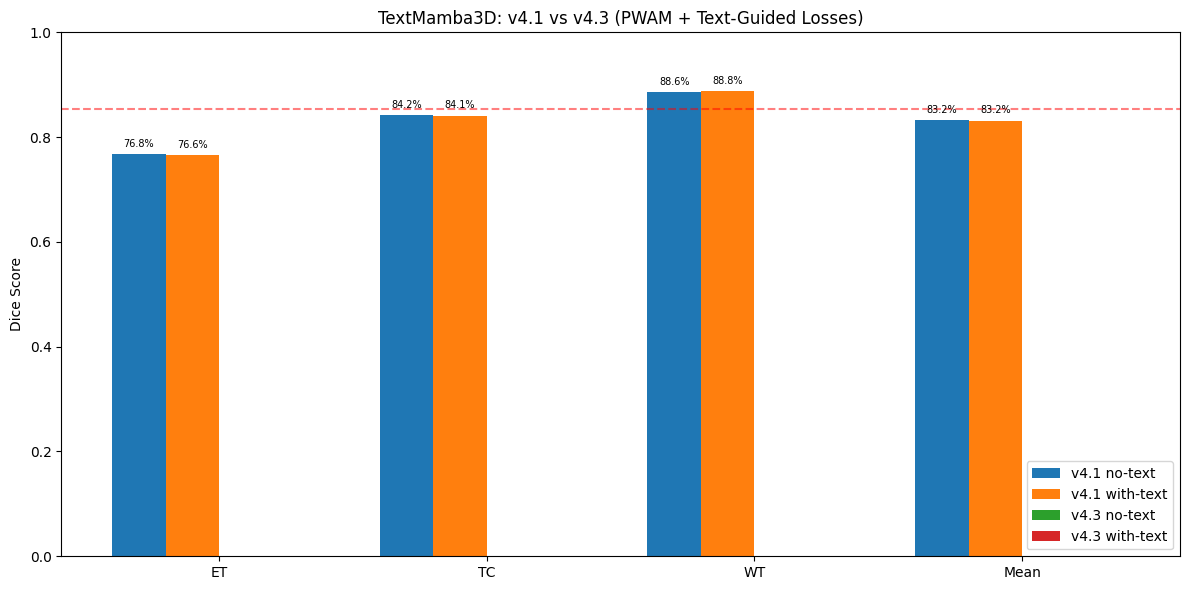

Fill in v4.3 Dice values after evaluation!


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Results comparison: v4 vs v4.2 vs v4.3
results = {
    "v4.1 no-text": {
        "dice": [0.7679, 0.8415, 0.8860, 0.8318],
        "label": "v4.1 no-text",
    },
    "v4.1 with-text": {
        "dice": [0.7663, 0.8411, 0.8875, 0.8316],
        "label": "v4.1 with-text",
    },
    "v4.3 no-text (bypass)": {
        "dice": [0.0, 0.0, 0.0, 0.0],  # FILL AFTER EVAL
        "label": "v4.3 no-text",
    },
    "v4.3 with-text (PWAM)": {
        "dice": [0.0, 0.0, 0.0, 0.0],  # FILL AFTER EVAL
        "label": "v4.3 with-text",
    },
}

regions = ["ET", "TC", "WT", "Mean"]
x = np.arange(len(regions))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, data) in enumerate(results.items()):
    bars = ax.bar(x + i * width, data["dice"], width, label=data["label"])
    for bar, val in zip(bars, data["dice"]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{val:.1%}', ha='center', va='bottom', fontsize=7)

ax.set_ylabel('Dice Score')
ax.set_title('TextMamba3D: v4.1 vs v4.3 (PWAM + Text-Guided Losses)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(regions)
ax.legend()
ax.set_ylim(0, 1.0)
ax.axhline(y=0.853, color='r', linestyle='--', alpha=0.5, label='SOTA (85.3%)')
plt.tight_layout()
plt.savefig("results_comparison_v43.png", dpi=150)
plt.show()

print("Fill in v4.3 Dice values after evaluation!")

## 7. Resume Training (After Colab Disconnect)

Resume from the last checkpoint saved to Drive.

In [17]:
import os, shutil
os.chdir(REPO_DIR)
os.environ["DRIVE_CKPT_DIR"] = DRIVE_CKPT

resume_ckpt = os.path.join(DRIVE_CKPT, "last.pth")
if os.path.exists(resume_ckpt):
    print(f"Resuming from {resume_ckpt}")
    !python train.py \
        --config configs/textbrats_v5.yaml \
        --resume "{resume_ckpt}" \
        --no-text-ratio 0.15 \
        --grad-accum 1

    sync_checkpoints_to_drive()

    best_ckpt = os.path.join(DRIVE_CKPT, "best_v4.3.pth")
    local_best = os.path.join(REPO_DIR, "checkpoints/best.pth")
    if os.path.exists(local_best):
        shutil.copy2(local_best, best_ckpt)
        print(f"Best checkpoint saved: {best_ckpt}")
else:
    print(f"No checkpoint found at {resume_ckpt}")
    print("Run the training cell (Section 5) first.")

Resuming from /content/drive/MyDrive/TextMamba3D/checkpoints/last.pth
2026-03-14 10:52:39.717184: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 10:52:39.739257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773485559.762503  110076 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773485559.770089  110076 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773485559.792175  110076 computation_placer.cc:177] computat